Q10
(a) Manual Bilateral Filter Implementation

In [3]:
import cv2 as cv
import numpy as np

def bilateral_filter_manual(img, diameter, sigma_s, sigma_r):
    """Manual bilateral filter for grayscale images."""
    h, w = img.shape
    pad = diameter // 2
    padded = cv.copyMakeBorder(img, pad, pad, pad, pad, cv.BORDER_REFLECT)
    output = np.zeros_like(img, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            # Extract local region
            region = padded[i:i+diameter, j:j+diameter]
            
            # Spatial Gaussian
            x, y = np.meshgrid(np.arange(diameter) - pad, np.arange(diameter) - pad)
            spatial = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
            
            # Range Gaussian
            center_val = padded[i+pad, j+pad]
            range_gauss = np.exp(-((region - center_val)**2) / (2 * sigma_r**2))
            
            # Combined weights
            weights = spatial * range_gauss
            weights /= np.sum(weights)
            
            # Weighted sum
            output[i, j] = np.sum(region * weights)
    
    return np.clip(output, 0, 255).astype(np.uint8)

# Load an image (grayscale or color)
img = cv.imread('/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 01/runway.png', cv.IMREAD_REDUCED_GRAYSCALE_2)
assert img is not None



(b) Gaussian Smoothing with OpenCV

In [4]:
gaussian_smoothed = cv.GaussianBlur(img, (5,5), 1.0)


(c) Bilateral Filtering with OpenCV

In [5]:
bilateral_cv = cv.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)


(d) Compare Gaussian Smoothing vs Bilateral Filtering(Manual) vs Bilateral Filtering(OpenCV)

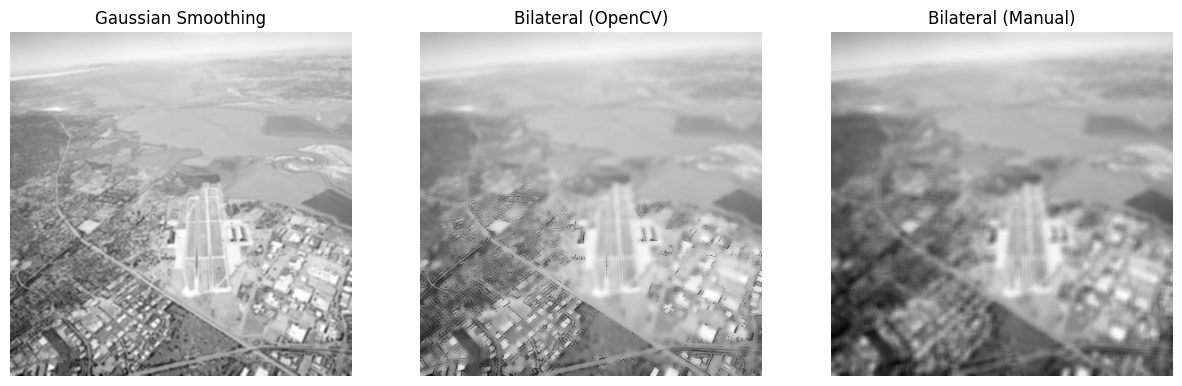

In [7]:
import matplotlib.pyplot as plt

manual = bilateral_filter_manual(img, diameter=9, sigma_s=5, sigma_r=12)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Gaussian Smoothing")
plt.imshow(gaussian_smoothed, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Bilateral (OpenCV)")
plt.imshow(bilateral_cv, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Bilateral (Manual)")
plt.imshow(manual, cmap='gray')
plt.axis("off")
plt.show()


Gaussian smoothing: Blurs noise but also blurs edges.
Bilateral filtering (OpenCV): Smooths noise while keeping edges sharp.
Manual bilateral filter: the manual version looks blurrier, this is due to lack of parameter tuning and normalization